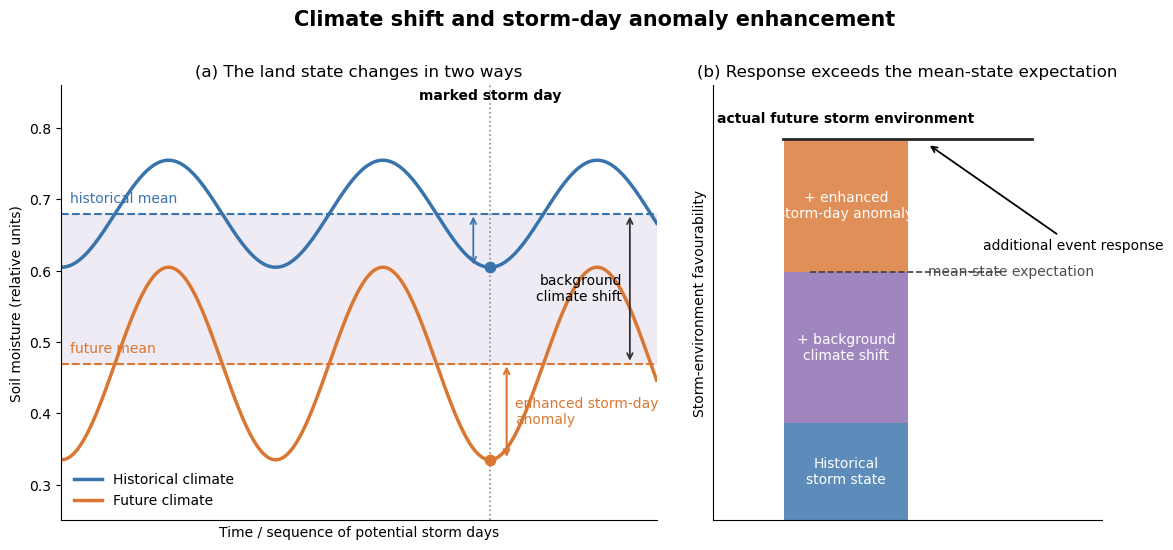

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False})

hist_col = '#3973ac'
fut_col  = '#d97732'
shift_col = '#8b6bb1'

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 5.4),
    gridspec_kw={'width_ratios': [1.3, 0.85]}
)

# ============================================================
# (a) Climate-mean shift + enhanced storm-day SM anomaly
# ============================================================
x = np.linspace(0, 10, 600)
storm_x = 7.2

hist_mean, fut_mean = 0.68, 0.47
phase = 2*np.pi*(x-storm_x)/3.6 - np.pi/2

# Conceptual variability—not model data
sm_hist = hist_mean + 0.075*np.sin(phase)
sm_fut  = fut_mean  + 0.135*np.sin(phase)

ih = np.argmin(abs(x-storm_x))
hist_event, fut_event = sm_hist[ih], sm_fut[ih]

# Climate-mean shift
ax1.axhspan(fut_mean, hist_mean, color=shift_col, alpha=0.13)
ax1.axhline(hist_mean, color=hist_col, ls='--', lw=1.5)
ax1.axhline(fut_mean,  color=fut_col,  ls='--', lw=1.5)

# Soil-moisture trajectories
ax1.plot(x, sm_hist, color=hist_col, lw=2.5, label='Historical climate')
ax1.plot(x, sm_fut,  color=fut_col,  lw=2.5, label='Future climate')

# Marked storm day
ax1.axvline(storm_x, color='0.55', ls=':', lw=1.2)
ax1.scatter(storm_x, hist_event, s=55, color=hist_col, zorder=5)
ax1.scatter(storm_x, fut_event,  s=55, color=fut_col,  zorder=5)
ax1.text(storm_x, 0.84, 'marked storm day', ha='center', weight='bold')

# Mean labels
ax1.text(0.15, hist_mean+0.015, 'historical mean', color=hist_col)
ax1.text(0.15, fut_mean+0.015,  'future mean', color=fut_col)

# Background climate shift bracket
ax1.annotate('', xy=(9.55, hist_mean), xytext=(9.55, fut_mean),
             arrowprops=dict(arrowstyle='<->', color='0.2', lw=1.3))
ax1.text(9.42, (hist_mean+fut_mean)/2,
         'background\nclimate shift', ha='right', va='center')

# Storm-day anomaly brackets
ax1.annotate('', xy=(storm_x-0.28, hist_mean),
             xytext=(storm_x-0.28, hist_event),
             arrowprops=dict(arrowstyle='<->', color=hist_col, lw=1.3))

ax1.annotate('', xy=(storm_x+0.28, fut_mean),
             xytext=(storm_x+0.28, fut_event),
             arrowprops=dict(arrowstyle='<->', color=fut_col, lw=1.5))

ax1.text(storm_x+0.42, (fut_mean+fut_event)/2,
         'enhanced storm-day\nanomaly', va='center', color=fut_col)

ax1.set(xlim=(0, 10), ylim=(0.25, 0.86),
        xlabel='Time / sequence of potential storm days',
        ylabel='Soil moisture (relative units)',
        title='(a) The land state changes in two ways')
ax1.set_xticks([])
ax1.legend(frameon=False, loc='lower left')

# ============================================================
# (b) Decomposition of the future storm environment
# ============================================================
hist_response = 0.55
climate_shift = 0.85
anomaly_enhancement = 0.75

bottoms = [0, hist_response, hist_response+climate_shift]
heights = [hist_response, climate_shift, anomaly_enhancement]
colors = [hist_col, shift_col, fut_col]

for bottom, height, color in zip(bottoms, heights, colors):
    ax2.bar(0, height, bottom=bottom, width=0.65,
            color=color, alpha=0.82)

mean_only = hist_response + climate_shift
actual_future = mean_only + anomaly_enhancement

ax2.axhline(mean_only, xmin=0.25, xmax=0.75,
            color='0.25', ls='--', lw=1.2)
ax2.axhline(actual_future, xmin=0.18, xmax=0.82,
            color='0.15', lw=2)

ax2.text(0, hist_response/2,
         'Historical\nstorm state', ha='center', va='center', color='white')

ax2.text(0, hist_response+climate_shift/2,
         '+ background\nclimate shift', ha='center', va='center', color='white')

ax2.text(0, mean_only+anomaly_enhancement/2,
         '+ enhanced\nstorm-day anomaly', ha='center', va='center', color='white')

ax2.text(0.43, mean_only, 'mean-state expectation',
         va='center', color='0.3')
ax2.text(0, actual_future+0.09,
         'actual future storm environment',
         ha='center', weight='bold')

ax2.annotate('additional event response',
             xy=(0.43, actual_future-0.03),
             xytext=(0.72, mean_only+0.15),
             arrowprops=dict(arrowstyle='->', lw=1.3),
             va='center')

ax2.set(xlim=(-0.7, 1.35), ylim=(0, 2.45),
        ylabel='Storm-environment favourability',
        title='(b) Response exceeds the mean-state expectation')
ax2.set_xticks([])
ax2.set_yticks([])

#fig.suptitle('Climate shift and storm-day anomaly enhancement',
#             fontsize=15, weight='bold', y=1.01)

fig.tight_layout()
plt.savefig('climate_shift_anomaly_schematic.pdf',
            bbox_inches='tight', dpi=300)
plt.savefig('climate_shift_anomaly_schematic.png',
            bbox_inches='tight', dpi=300)
plt.show()